In [ ]:
import os
import numpy as np
import pandas as pd
import rasterio
from PIL import Image
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils import shuffle
import joblib

## Pre-processing

In [2]:
# Path ke folder image dan label
image_dir = 'E:\\FOLU NET SINK 2030\\Data_OSM_ML\\Image'  # Ganti sesuai lokasi folder image
label_dir = 'E:\\FOLU NET SINK 2030\\Data_OSM_ML\\Label'  # Ganti sesuai lokasi folder label

In [ ]:
# Fungsi untuk menghubungkan antara image dan label
def collect_file_paths(image_dir, label_dir, extension_image='.tif', extension_label='.png'):
    image_paths = []
    label_paths = []
    
    # Iterate through all files in the image directory
    for filename in os.listdir(image_dir):
        if filename.endswith(extension_image):
            # Full path for image
            image_path = os.path.join(image_dir, filename)
            
            # Construct corresponding label path
            label_filename = filename.replace(extension_image, extension_label)
            label_path = os.path.join(label_dir, label_filename)
            
            # Check if label exists before adding
            if os.path.exists(label_path):
                image_paths.append(image_path)
                label_paths.append(label_path)
            else:
                print(f"Label file missing for {filename}")
    
    return image_paths, label_paths

In [ ]:
# Verify counts
image_paths, label_paths = collect_file_paths(image_dir, label_dir)
print(f"Total images found: {len(image_paths)}")
print(f"Total labels found: {len(label_paths)}")

Total images found: 1000
Total labels found: 1000


In [ ]:
# Membaca label dan mengonversikan menjadi kelas biner
def read_label(path_label):
    """ Membaca label dan mengonversi ke dua kelas: 'wooded' dan 'non-wooded' """
    label_img = np.array(Image.open(path_label))
    label = np.zeros_like(label_img[:, :, 0])
    label[label_img[:, :, 0] == 0] = 1  # 'wooded' menjadi 1
    label[label_img[:, :, 0] != 0] = 0  # Semua kelas lain menjadi 'non-wooded' (0)
    return label

# Membaca dan Menyiapkan Data Fitur dari Citra Sentinel
def read_image(path_image):
    """ Membaca image dan mengembalikan array 4 band """
    with rasterio.open(path_image) as src:
        image = src.read([1, 2, 3, 4])  # Membaca 4 band
        image = np.moveaxis(image, 0, -1)  # Ubah dimensi ke (192, 192, 4)
    return image

In [ ]:
# Ekstraksi Fitur dan Label
def extract_features_labels(image, label):
    """ Ekstraksi fitur dan label """
    features = image.reshape(-1, 4)
    labels = label.reshape(-1)
    mask = labels >= 0  # Memastikan semua data dengan label valid
    return features[mask], labels[mask]

In [7]:
# Menggabungkan semua data dari semua file menjadi satu dataset
all_features = []
all_labels = []

for img_path, lbl_path in zip(image_paths, label_paths):
    image = read_image(img_path)
    label = read_label(lbl_path)
    features, labels = extract_features_labels(image, label)
    all_features.append(features)
    all_labels.append(labels)

In [8]:
# Menggabungkan semua fitur dan label dari setiap citra
all_features = np.concatenate(all_features, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Memeriksa bentuk akhir dataset
print("Total Features shape:", all_features.shape)
print("Total Labels shape:", all_labels.shape)

Total Features shape: (36864000, 4)
Total Labels shape: (36864000,)


In [ ]:
# Membagi Dataset untuk Latih dan Uji
X_train, X_test, y_train, y_test = train_test_split(all_features, all_labels, test_size=0.2, random_state=42)

## Random Forest

In [10]:
# Fungsi untuk melatih dalam batch
def batch_training(X, y, model, batch_size=10000):
    n_samples = X.shape[0]
    n_batches = n_samples // batch_size
    for i in range(n_batches + 1):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, n_samples)
        if start_idx >= n_samples:
            break
        X_batch = X[start_idx:end_idx]
        y_batch = y[start_idx:end_idx]
        model.fit(X_batch, y_batch)  # Update model with each batch
        print(f"Batch {i + 1}/{n_batches + 1} processed")

In [ ]:
# Ubah cara kita memanggil pelatihan model
batch_size = 10000  # Sesuaikan sesuai kapasitas memori yang tersedia
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Memastikan data tercampur sebelum di-batch untuk pelatihan
X_shuffled, y_shuffled = shuffle(all_features, all_labels, random_state=42)

In [12]:
# Melatih dalam batch
batch_training(X_shuffled, y_shuffled, rf, batch_size=batch_size)

Batch 1/3687 processed
Batch 2/3687 processed
Batch 3/3687 processed
Batch 4/3687 processed
Batch 5/3687 processed
Batch 6/3687 processed
Batch 7/3687 processed
Batch 8/3687 processed
Batch 9/3687 processed
Batch 10/3687 processed
Batch 11/3687 processed
Batch 12/3687 processed
Batch 13/3687 processed
Batch 14/3687 processed
Batch 15/3687 processed
Batch 16/3687 processed
Batch 17/3687 processed
Batch 18/3687 processed
Batch 19/3687 processed
Batch 20/3687 processed
Batch 21/3687 processed
Batch 22/3687 processed
Batch 23/3687 processed
Batch 24/3687 processed
Batch 25/3687 processed
Batch 26/3687 processed
Batch 27/3687 processed
Batch 28/3687 processed
Batch 29/3687 processed
Batch 30/3687 processed
Batch 31/3687 processed
Batch 32/3687 processed
Batch 33/3687 processed
Batch 34/3687 processed
Batch 35/3687 processed
Batch 36/3687 processed
Batch 37/3687 processed
Batch 38/3687 processed
Batch 39/3687 processed
Batch 40/3687 processed
Batch 41/3687 processed
Batch 42/3687 processed
B

In [13]:
# Evaluasi model
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7046181911892361
              precision    recall  f1-score   support

           0       0.68      0.64      0.66   3298137
           1       0.72      0.75      0.74   4074663

    accuracy                           0.70   7372800
   macro avg       0.70      0.70      0.70   7372800
weighted avg       0.70      0.70      0.70   7372800



In [ ]:
# Menyimpan model Random Forest
joblib.dump(rf, 'rf_model_osm.joblib')

['rf_model_osm.joblib']

## Support Vector Machine

In [15]:
# Model SVM dengan kernel linear (sesuaikan kernel sesuai kebutuhan)
svm_model = SVC(kernel='linear', random_state=42)

# Subsampling atau batch size untuk menangani keterbatasan memori
batch_size = 5000  # Sesuaikan batch size sesuai dengan kapasitas memori yang tersedia

# Acak data sebelum batching
X_shuffled, y_shuffled = shuffle(all_features, all_labels, random_state=42)

# Memilih subset data untuk batch pertama
X_train_batch = X_shuffled[:batch_size]
y_train_batch = y_shuffled[:batch_size]

# Latih model SVM pada batch pertama
svm_model.fit(X_train_batch, y_train_batch)

SVC(kernel='linear', random_state=42)

In [16]:
# Evaluasi pada data uji
svm_pred = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.6556235080295139
              precision    recall  f1-score   support

           0       0.72      0.38      0.50   3298137
           1       0.64      0.88      0.74   4074663

    accuracy                           0.66   7372800
   macro avg       0.68      0.63      0.62   7372800
weighted avg       0.67      0.66      0.63   7372800



In [ ]:
# Menyimpan model SVM
joblib.dump(svm_model, 'svm_model_osm.joblib')

['svm_model_osm.joblib']

## Gradient Boosting

In [18]:
# Inisialisasi model Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Subsampling atau batch size untuk mengelola memori
batch_size = 5000  # Sesuaikan dengan kapasitas memori

# Acak data sebelum melakukan batching
X_shuffled, y_shuffled = shuffle(all_features, all_labels, random_state=42)

# Ambil batch pertama dari data acak
X_train_batch = X_shuffled[:batch_size]
y_train_batch = y_shuffled[:batch_size]

# Melatih model pada batch pertama
gb_model.fit(X_train_batch, y_train_batch)

GradientBoostingClassifier(random_state=42)

In [19]:
# Evaluasi model pada data uji
gb_pred = gb_model.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 0.715709228515625
              precision    recall  f1-score   support

           0       0.69      0.65      0.67   3298137
           1       0.73      0.77      0.75   4074663

    accuracy                           0.72   7372800
   macro avg       0.71      0.71      0.71   7372800
weighted avg       0.71      0.72      0.71   7372800



In [20]:
# Menyimpan model Gradient Boosting
joblib.dump(gb_model, 'GB_model_osm.joblib')

['GB_model_osm.joblib']

## Naive Bayes

In [ ]:
# Inisialisasi model Naive Bayes
nb_model = GaussianNB()

# Subsampling atau batch size untuk mengelola memori
batch_size = 5000  # Sesuaikan ukuran batch sesuai dengan kapasitas memori

# Dapatkan jumlah kelas unik untuk inisialisasi pertama partial_fit
classes = np.unique(all_labels)

# Shuffle data untuk memastikan setiap batch mewakili semua kelas secara proporsional
X_shuffled, y_shuffled = shuffle(all_features, all_labels, random_state=42)

# Pelatihan dengan batch menggunakan partial_fit
for i in range(0, len(X_shuffled), batch_size):
    X_batch = X_shuffled[i:i + batch_size]
    y_batch = y_shuffled[i:i + batch_size]
    
    # Memanggil partial_fit pada batch pertama untuk inisialisasi dengan daftar kelas
    nb_model.partial_fit(X_batch, y_batch, classes=classes) if i == 0 else nb_model.partial_fit(X_batch, y_batch)

# Evaluasi model pada data uji
nb_pred = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.5730164930555556
              precision    recall  f1-score   support

           0       0.64      0.10      0.18   3298137
           1       0.57      0.95      0.71   4074663

    accuracy                           0.57   7372800
   macro avg       0.60      0.53      0.45   7372800
weighted avg       0.60      0.57      0.47   7372800



In [22]:
# Menyimpan model Gradient Boosting
joblib.dump(nb_model, 'nb_model_osm.joblib')

['nb_model_osm.joblib']

## Predict

In [ ]:
import joblib
import rasterio
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Muat model dari file
model_path = 'E:\\FOLU NET SINK 2030\\Script\\rf_model_osm.joblib'  # Ganti dengan path model yang disimpan
model = joblib.load(model_path)

In [ ]:
# Path ke data citra baru
new_image_path = 'E:\\FOLU NET SINK 2030\\filter_osm_sentinel_imagery\\image\\124700082.tif'  # Ganti dengan path citra baru

with rasterio.open(new_image_path) as src:
    # Baca seluruh 4 band untuk prediksi
    new_image = src.read([1, 2, 3, 4])
    new_image = np.moveaxis(new_image, 0, -1)  # Ubah dimensi ke (height, width, channels)
    
    # Buat komposit RGB untuk visualisasi
    rgb_image = new_image[:, :, [0, 1, 2]]  # Ambil band 4 (red), 3 (green), dan 2 (blue) untuk komposit RGB
    rgb_image = rgb_image / np.max(rgb_image)  # Normalisasi antara 0 dan 1 untuk tampilan

In [25]:
# Mengubah citra menjadi bentuk (N, 4) di mana N adalah jumlah piksel
new_image_features = new_image.reshape(-1, new_image.shape[-1])

# Prediksi kelas setiap piksel
predicted_labels = model.predict(new_image_features)

# Ubah hasil prediksi kembali ke dimensi spasial asli
predicted_labels = predicted_labels.reshape(new_image.shape[0], new_image.shape[1])

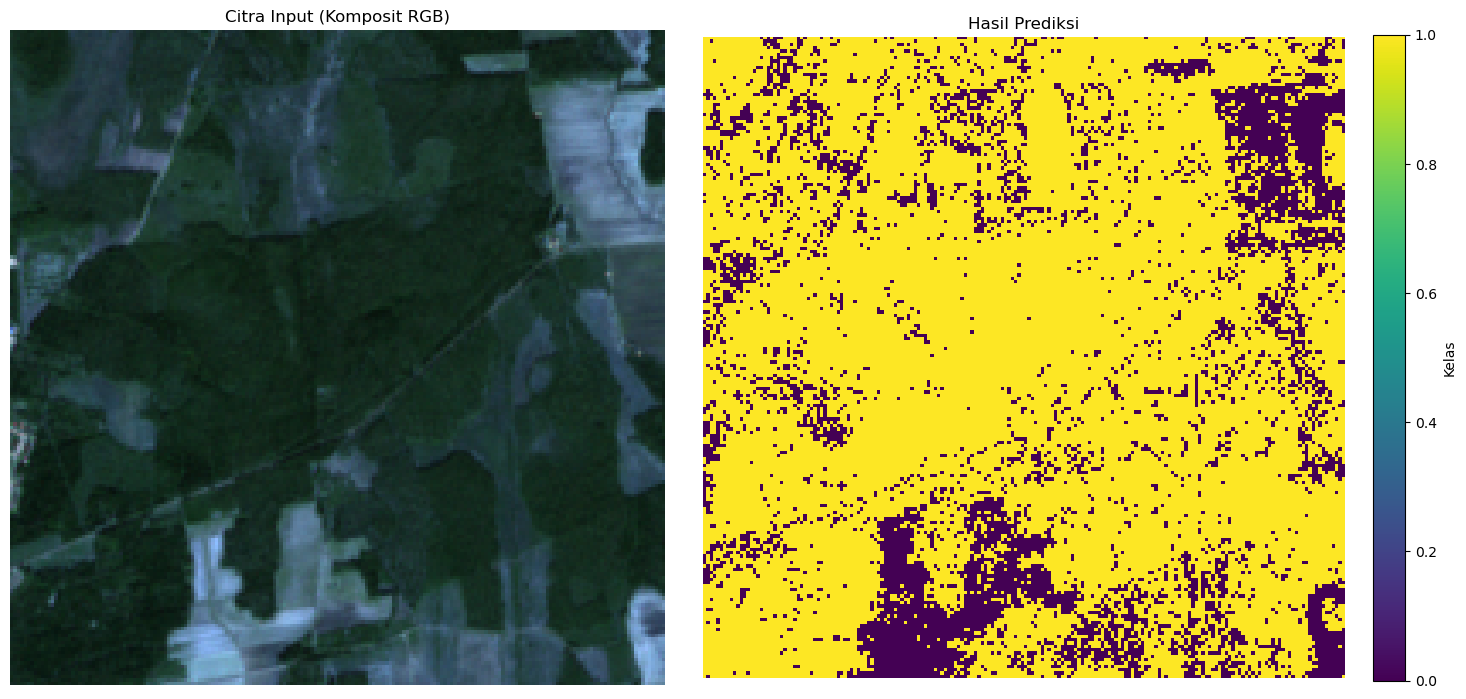

In [ ]:
## Membuat subplot untuk menampilkan citra komposit RGB dan hasil prediksi
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Visualisasi citra komposit RGB
axes[0].imshow(rgb_image)  # Tampilkan RGB image
axes[0].set_title("Citra Input (Komposit RGB)")
axes[0].axis('off')  # Nonaktifkan sumbu

# Visualisasi hasil prediksi
im = axes[1].imshow(predicted_labels, cmap='viridis')  # Tampilkan hasil prediksi dengan colormap
axes[1].set_title("Hasil Prediksi")
axes[1].axis('off')  # Nonaktifkan sumbu

# Tambahkan color bar untuk hasil prediksi
cbar = fig.colorbar(im, ax=axes[1], orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label("Kelas")  # Label untuk color bar

# Tampilkan plot
plt.tight_layout()
plt.show()